# 07 — Sentiment Feature Ablation

**Question:** Do AAII `bullish`/`bearish` sentiment features improve 21-day
forward realized-volatility forecasts compared to a price/volume-only baseline?

## Experimental design

| Variant | Features | n_features |
|---------|----------|------------|
| **No-sentiment** | `log_return`, `abs_return`, `oc_return`, `intraday_range`, `relative_volume_21d` | 5 |
| **With-sentiment** | same 5 + `bullish`, `bearish` | 7 |

Tested on **both model families** in this project:

1. **Baseline LSTM** — single monolithic LSTM using Optuna-tuned HPs from `models/lstm_baseline.pt`.
2. **Regime Ensemble** — calm + volatile LSTMs blended by HMM soft probabilities, using Optuna-tuned HPs
   from `models/lstm_calm.pt` / `models/lstm_volatile.pt`.

All models are **retrained from scratch** with a fixed seed, the same epoch budget, and identical
early-stopping patience. The saved HPs are reused as-is so architecture choices cannot explain any gap.
Metrics are reported in the **original volatility scale** (`exp(pred)`).

In [1]:
import sys
import time
import warnings
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

import config
from src.hmm_model import (
    fit_scaler,
    forward_backward_proba,
    identify_volatile_state,
    train_gaussian_hmm,
    viterbi_decode,
)
from src.lstm_model import LSTMRegressor, VolatilityWindowDataset
from src.utils import regression_metrics

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("LSTM_STATIONARY_FEATURES :", config.LSTM_STATIONARY_FEATURES)
print("SENTIMENT_FEATURES       :", config.SENTIMENT_FEATURES)
print("LSTM_BASELINE_FEATURES   :", config.LSTM_BASELINE_FEATURES)

LSTM_STATIONARY_FEATURES : ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'relative_volume_21d']
SENTIMENT_FEATURES       : ['bullish', 'bearish']
LSTM_BASELINE_FEATURES   : ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'relative_volume_21d', 'bullish', 'bearish']


## 1 — Load data splits and saved hyperparameters

In [2]:
train_df = pd.read_parquet(config.DATA_PROCESSED / "train.parquet")
val_df   = pd.read_parquet(config.DATA_PROCESSED / "val.parquet")
test_df  = pd.read_parquet(config.DATA_PROCESSED / "test.parquet")
rp       = pd.read_parquet(config.DATA_PROCESSED / "regime_probabilities.parquet")
meta     = joblib.load(config.MODELS_DIR / "hmm_meta.joblib")

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}  {df.index[0].date()} \u2192 {df.index[-1].date()}  ({len(df):,} rows)")


def _load_hps(model_name: str) -> dict:
    ckpt = torch.load(
        str(config.MODELS_DIR / f"lstm_{model_name}.pt"),
        map_location="cpu",
        weights_only=False,
    )
    return ckpt["hyperparameters"]


BASELINE_HPS = _load_hps("baseline")
CALM_HPS     = _load_hps("calm")
VOLATILE_HPS = _load_hps("volatile")

print()
for label, hps in [("baseline", BASELINE_HPS), ("calm", CALM_HPS), ("volatile", VOLATILE_HPS)]:
    print(f"  {label:>8} HPs: {hps}")

train  2004-01-05 → 2018-12-31  (3,774 rows)
val    2019-01-02 → 2021-12-31  (757 rows)
test   2022-01-03 → 2026-03-16  (1,053 rows)

  baseline HPs: {'hidden_size': 128, 'n_layers': 3, 'dropout': 0.07563363436117017, 'lr': 0.009818247569037463, 'batch_size': 64, 'seq_len': 42}
      calm HPs: {'hidden_size': 32, 'n_layers': 1, 'dropout': 0.46887943962772105, 'lr': 0.0008476798466510087, 'batch_size': 64, 'seq_len': 21}
  volatile HPs: {'hidden_size': 32, 'n_layers': 3, 'dropout': 0.49826330933920426, 'lr': 0.0019110922048796155, 'batch_size': 128, 'seq_len': 42}


## 2 — Helpers

In [3]:
FEAT_NO_SENT   = config.LSTM_STATIONARY_FEATURES   # 5 features
FEAT_WITH_SENT = config.LSTM_BASELINE_FEATURES      # 7 features (5 + bullish + bearish)
HMM_FEAT_NO_SENT   = config.HMM_PRICE_VOLUME_FEATURES
HMM_FEAT_WITH_SENT = config.HMM_FEATURES
TARGET         = config.LSTM_TARGET
SEED           = config.LSTM_RANDOM_STATE
EPOCHS         = config.LSTM_FINAL_EPOCHS
PATIENCE       = config.LSTM_PATIENCE
CALM_STATE     = meta["calm_state"]
VOLATILE_STATE = meta["volatile_state"]
MIN_VAL_WINDOWS = 1   # fallback threshold, mirrors train_LSTM_regime.py


def set_seed(s: int) -> None:
    np.random.seed(s)
    torch.manual_seed(s)


def prepare(df: pd.DataFrame, features: list[str]):
    """Drop NaN rows; return (X_raw float64, y_log float64, date_index)."""
    sub = df[features + [TARGET]].dropna()
    X = sub[features].to_numpy(np.float64)
    y = np.log(sub[TARGET].to_numpy(np.float64))
    return X, y, sub.index


def _loader(X, y, seq_len: int, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        VolatilityWindowDataset(X, y, seq_len),
        batch_size=batch_size,
        shuffle=shuffle,
    )


def _train_loop(model, tr_ldr, vl_ldr, lr: float, epochs: int, patience: int):
    """Adam + early-stopping on val MSE (original scale). Returns (model, best_val_mse)."""
    opt      = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn  = nn.MSELoss()
    best_mse = float("inf")
    best_state = None
    stale    = 0
    for epoch in range(1, epochs + 1):
        model.train()
        for x, y in tr_ldr:
            opt.zero_grad()
            loss_fn(model(x), y).backward()
            opt.step()
        model.eval()
        ps, ts = [], []
        with torch.no_grad():
            for x, y in vl_ldr:
                ps.append(model(x).numpy())
                ts.append(y.numpy())
        mse = float(np.mean(
            (np.exp(np.concatenate(ps)) - np.exp(np.concatenate(ts))) ** 2
        ))
        if mse < best_mse:
            best_mse   = mse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            stale      = 0
        else:
            stale += 1
        if stale >= patience:
            print(f"      \u21b3 early stop @ epoch {epoch}")
            break
    model.load_state_dict(best_state)
    return model, best_mse


def _infer(model, X, y, seq_len: int, batch_size: int, index) -> tuple:
    """Full inference; returns (pred_raw, target_raw, aligned_index)."""
    ldr = _loader(X, y, seq_len, batch_size, shuffle=False)
    model.eval()
    ps, ts = [], []
    with torch.no_grad():
        for x, yb in ldr:
            ps.append(model(x).numpy())
            ts.append(yb.numpy())
    return (
        np.exp(np.concatenate(ps)),
        np.exp(np.concatenate(ts)),
        index[seq_len - 1:],
    )


# ── Regime helpers (mirrors train_LSTM_regime.py) ─────────────────────────────

class _RegimeDataset(Dataset):
    """Sliding-window dataset retaining only dominant-regime windows."""

    def __init__(self, X, y, viterbi, seq_len: int, target_state: int):
        self.X  = torch.as_tensor(X, dtype=torch.float32)
        self.y  = torch.as_tensor(y, dtype=torch.float32)
        self.vi = viterbi.astype(int)
        self.sl = seq_len
        n = len(X)
        self.valid = [
            i for i in range(n - seq_len + 1)
            if int(np.argmax(np.bincount(self.vi[i : i + seq_len], minlength=2))) == target_state
        ]

    def __len__(self):
        return len(self.valid)

    def __getitem__(self, i):
        j = self.valid[i]
        return self.X[j : j + self.sl], self.y[j + self.sl - 1]


def _viterbi_for(df: pd.DataFrame, features: list[str], rp_variant: pd.DataFrame) -> np.ndarray:
    """Viterbi labels aligned to the NaN-dropped rows of df for these features."""
    idx = df[features + [TARGET]].dropna().index
    return rp_variant["viterbi_state"].reindex(idx).fillna(CALM_STATE).astype(int).values


def fit_variant_hmm_posteriors(
    hmm_features: list[str],
    variant_name: str,
    save_tag: str,
) -> dict:
    """Fit a variant-specific GaussianHMM and export its posterior probabilities."""
    print(f"\n[HMM — {variant_name}]  {len(hmm_features)} features")

    tr = train_df[hmm_features].dropna()
    vl = val_df[hmm_features].dropna()
    te = test_df[hmm_features].dropna()

    X_tr = tr.to_numpy(np.float64)
    X_vl = vl.to_numpy(np.float64)
    X_te = te.to_numpy(np.float64)

    scaler = fit_scaler(X_tr)
    X_tr_s = scaler.transform(X_tr)
    X_vl_s = scaler.transform(X_vl)
    X_te_s = scaler.transform(X_te)

    vol_idx = hmm_features.index("abs_return") if "abs_return" in hmm_features else 1
    hmm_model = train_gaussian_hmm(
        X_tr_s,
        n_states=config.HMM_N_STATES,
        covariance_type=config.HMM_COVARIANCE_TYPE,
        n_iter=config.HMM_N_ITER,
        random_state=config.HMM_RANDOM_STATE,
        n_restarts=config.HMM_N_RESTARTS,
        duration_penalty=config.HMM_DURATION_PENALTY,
        vol_feature_idx=vol_idx,
    )

    tr_states = viterbi_decode(hmm_model, X_tr_s)
    state_map = identify_volatile_state(
        hmm_model,
        X_tr_s,
        tr_states,
        feature_idx=vol_idx,
    )
    calm_state = state_map["calm"]
    volatile_state = state_map["volatile"]

    def _infer_split(idx: pd.Index, X_scaled: np.ndarray) -> pd.DataFrame:
        proba = forward_backward_proba(hmm_model, X_scaled)
        states = viterbi_decode(hmm_model, X_scaled)
        return pd.DataFrame(
            {
                "p_calm": proba[:, calm_state],
                "p_volatile": proba[:, volatile_state],
                "viterbi_state": states,
                "regime_label": ["volatile" if s == volatile_state else "calm" for s in states],
            },
            index=idx,
        )

    rp_variant = pd.concat(
        [
            _infer_split(tr.index, X_tr_s),
            _infer_split(vl.index, X_vl_s),
            _infer_split(te.index, X_te_s),
        ]
    ).sort_index()

    save_path = config.DATA_PROCESSED / f"regime_probabilities_{save_tag}.parquet"
    rp_variant.to_parquet(save_path)

    pct_vol = 100.0 * (rp_variant.loc[te.index, "p_volatile"] > 0.5).mean()
    print(
        f"  saved posteriors -> {save_path.name}  "
        f"| volatile_state={volatile_state}  "
        f"| test days p_vol>0.5: {pct_vol:.1f}%"
    )

    return {
        "rp": rp_variant,
        "calm_state": calm_state,
        "volatile_state": volatile_state,
        "hmm_features": hmm_features,
    }


print("Helpers ready.")

Helpers ready.


## 3 — Training functions

In [4]:
def train_baseline(features: list[str], hps: dict, label: str) -> dict:
    """
    Train a single monolithic LSTM with fixed hyperparameters and evaluate on
    the full test set.

    Returns a dict with keys: label, features, val_mse, pred, target, dates,
    MSE, RMSE, MAE, MAPE.
    """
    print(f"\n[Baseline \u2014 {label}]  {len(features)} features  "
          f"hidden={hps['hidden_size']}  layers={hps['n_layers']}  seq_len={hps['seq_len']}")
    set_seed(SEED)

    X_tr, y_tr, _      = prepare(train_df, features)
    X_vl, y_vl, _      = prepare(val_df,   features)
    X_te, y_te, te_idx = prepare(test_df,  features)

    sc = StandardScaler().fit(X_tr)
    X_tr, X_vl, X_te = sc.transform(X_tr), sc.transform(X_vl), sc.transform(X_te)

    tr_ldr = _loader(X_tr, y_tr, hps["seq_len"], hps["batch_size"], shuffle=True)
    vl_ldr = _loader(X_vl, y_vl, hps["seq_len"], hps["batch_size"], shuffle=False)

    model = LSTMRegressor(
        input_size=len(features),
        hidden_size=hps["hidden_size"],
        n_layers=hps["n_layers"],
        dropout=hps["dropout"],
    )
    model, val_mse = _train_loop(model, tr_ldr, vl_ldr, hps["lr"], EPOCHS, PATIENCE)

    pred, target, dates = _infer(model, X_te, y_te, hps["seq_len"], hps["batch_size"], te_idx)
    m = regression_metrics(target, pred)
    print(f"  val MSE (raw): {val_mse:.8f}  \u2502  "
          f"test RMSE: {m['RMSE']:.6f}  MAPE: {m['MAPE']:.2f}%")
    return {
        "label": label, "features": features,
        "val_mse": val_mse, "pred": pred, "target": target, "dates": dates,
        **m,
    }


def train_ensemble(
    features: list[str],
    calm_hps: dict,
    vol_hps: dict,
    label: str,
    rp_variant: pd.DataFrame,
    calm_state: int,
    volatile_state: int,
) -> dict:
    """
    Train calm + volatile LSTMs on regime-filtered windows (same logic as
    train_LSTM_regime.py), then blend with HMM soft probabilities.

    Returns a dict with keys: label, features, df (aligned predictions),
    ensemble / calm / volatile (metric dicts).
    """
    print(f"\n[Ensemble \u2014 {label}]  {len(features)} features")
    set_seed(SEED)

    X_tr, y_tr, _      = prepare(train_df, features)
    X_vl, y_vl, _      = prepare(val_df,   features)
    X_te, y_te, te_idx = prepare(test_df,  features)

    # Scaler fit on full train (both regimes share the same scale)
    sc = StandardScaler().fit(X_tr)
    X_tr, X_vl, X_te = sc.transform(X_tr), sc.transform(X_vl), sc.transform(X_te)

    vi_tr = _viterbi_for(train_df, features, rp_variant)
    vi_vl = _viterbi_for(val_df,   features, rp_variant)

    preds = {}
    for regime, hps, state in [
        ("calm",     calm_hps, calm_state),
        ("volatile", vol_hps,  volatile_state),
    ]:
        print(f"  [{regime}]  hidden={hps['hidden_size']}  n_layers={hps['n_layers']}  "
              f"seq_len={hps['seq_len']}  dropout={hps['dropout']:.3f}")
        set_seed(SEED)

        tr_ds  = _RegimeDataset(X_tr, y_tr, vi_tr, hps["seq_len"], state)
        vl_ds  = _RegimeDataset(X_vl, y_vl, vi_vl, hps["seq_len"], state)
        tr_ldr = DataLoader(tr_ds, batch_size=hps["batch_size"], shuffle=True)
        # Fall back to full val loader if too few regime windows exist
        vl_ldr = (
            DataLoader(vl_ds, batch_size=hps["batch_size"], shuffle=False)
            if len(vl_ds) >= MIN_VAL_WINDOWS
            else _loader(X_vl, y_vl, hps["seq_len"], hps["batch_size"], shuffle=False)
        )

        model = LSTMRegressor(
            input_size=len(features),
            hidden_size=hps["hidden_size"],
            n_layers=hps["n_layers"],
            dropout=hps["dropout"],
        )
        model, _ = _train_loop(model, tr_ldr, vl_ldr, hps["lr"], EPOCHS, PATIENCE)

        # Evaluate on the FULL test set (not regime-filtered) so predictions
        # cover all dates needed for the ensemble blend
        pred_raw, _, dates = _infer(model, X_te, y_te, hps["seq_len"], hps["batch_size"], te_idx)
        preds[regime] = pd.Series(pred_raw, index=dates, name=regime)

    # Align calm, volatile, target and HMM probabilities by date index.
    # After the outer join, the longest seq_len (volatile=42) determines the
    # start date; dropna() handles the remaining gaps.
    df = pd.concat(preds.values(), axis=1)
    df["target"] = test_df[TARGET]   # pandas aligns by date index
    df = df.join(rp_variant[["p_calm", "p_volatile"]], how="inner").dropna()
    df["ensemble"] = df["p_calm"] * df["calm"] + df["p_volatile"] * df["volatile"]

    m_ens  = regression_metrics(df["target"].values, df["ensemble"].values)
    m_calm = regression_metrics(df["target"].values, df["calm"].values)
    m_vol  = regression_metrics(df["target"].values, df["volatile"].values)
    print(f"  test RMSE \u2014 calm: {m_calm['RMSE']:.6f}  "
          f"volatile: {m_vol['RMSE']:.6f}  "
          f"ensemble: {m_ens['RMSE']:.6f}  MAPE: {m_ens['MAPE']:.2f}%")
    return {
        "label": label, "features": features, "df": df,
        "ensemble": m_ens, "calm": m_calm, "volatile": m_vol,
    }

## 4 — Train all 4 variants

Each variant is trained from scratch with the saved Optuna hyperparameters.

In [5]:
t0 = time.time()
print("=" * 60)
print(" TRAINING 4 VARIANTS  (2 feature sets \u00d7 2 model families)")
print("=" * 60)

# Fit/export separate HMM posteriors for each feature variant.
hmm_no = fit_variant_hmm_posteriors(
    HMM_FEAT_NO_SENT,
    variant_name="no sentiment",
    save_tag="no_sent",
)
hmm_sent = fit_variant_hmm_posteriors(
    HMM_FEAT_WITH_SENT,
    variant_name="with sentiment",
    save_tag="with_sent",
)

base_no   = train_baseline(FEAT_NO_SENT,   BASELINE_HPS, "no sentiment")
base_sent = train_baseline(FEAT_WITH_SENT, BASELINE_HPS, "with sentiment")

ens_no    = train_ensemble(
    FEAT_NO_SENT,
    CALM_HPS,
    VOLATILE_HPS,
    "no sentiment",
    rp_variant=hmm_no["rp"],
    calm_state=hmm_no["calm_state"],
    volatile_state=hmm_no["volatile_state"],
)
ens_sent  = train_ensemble(
    FEAT_WITH_SENT,
    CALM_HPS,
    VOLATILE_HPS,
    "with sentiment",
    rp_variant=hmm_sent["rp"],
    calm_state=hmm_sent["calm_state"],
    volatile_state=hmm_sent["volatile_state"],
)

print(f"\nTotal training time: {time.time() - t0:.1f}s")

 TRAINING 4 VARIANTS  (2 feature sets × 2 model families)

[Baseline — no sentiment]  5 features  hidden=128  layers=3  seq_len=42
      ↳ early stop @ epoch 18
  val MSE (raw): 0.00008040  │  test RMSE: 0.004923  MAPE: 45.17%

[Baseline — with sentiment]  7 features  hidden=128  layers=3  seq_len=42
      ↳ early stop @ epoch 29
  val MSE (raw): 0.00005213  │  test RMSE: 0.004135  MAPE: 25.51%

[Ensemble — no sentiment]  5 features
  [calm]  hidden=32  n_layers=1  seq_len=21  dropout=0.469
      ↳ early stop @ epoch 16
  [volatile]  hidden=32  n_layers=3  seq_len=42  dropout=0.498
      ↳ early stop @ epoch 32
  test RMSE — calm: 0.005314  volatile: 0.008727  ensemble: 0.004661  MAPE: 25.94%

[Ensemble — with sentiment]  7 features
  [calm]  hidden=32  n_layers=1  seq_len=21  dropout=0.469
      ↳ early stop @ epoch 16
  [volatile]  hidden=32  n_layers=3  seq_len=42  dropout=0.498
      ↳ early stop @ epoch 34
  test RMSE — calm: 0.005243  volatile: 0.008907  ensemble: 0.003837  MAPE:

## 5 — Metrics comparison

In [6]:
METRIC_COLS = ("MSE", "RMSE", "MAE", "MAPE")

rows = [
    {"Family": "Baseline", "Sentiment": "no",
     **{k: base_no[k]              for k in METRIC_COLS}},
    {"Family": "Baseline", "Sentiment": "yes",
     **{k: base_sent[k]            for k in METRIC_COLS}},
    {"Family": "Ensemble", "Sentiment": "no",
     **{k: ens_no["ensemble"][k]   for k in METRIC_COLS}},
    {"Family": "Ensemble", "Sentiment": "yes",
     **{k: ens_sent["ensemble"][k] for k in METRIC_COLS}},
]
summary = pd.DataFrame(rows).set_index(["Family", "Sentiment"])

# Sentiment delta rows  (positive = sentiment hurts, negative = sentiment helps)
delta_rows = []
for fam in ("Baseline", "Ensemble"):
    d = summary.loc[(fam, "yes")] - summary.loc[(fam, "no")]
    d.name = (fam, "\u0394 (yes \u2212 no)")
    delta_rows.append(d.to_frame().T)

full_table = pd.concat([summary, *delta_rows])

with pd.option_context(
    "display.float_format",
    lambda x: f"{x:+.8f}" if abs(x) < 0.001 else f"{x:+.4f}",
):
    print(full_table.to_string())

print("\nKey: \u0394 < 0 means +sentiment improves the metric (helps);  \u0394 > 0 means it hurts.")
print("MAPE unit is %.")

                              MSE        RMSE         MAE     MAPE
Baseline no           +0.00002423     +0.0049     +0.0038 +45.1661
         yes          +0.00001710     +0.0041     +0.0025 +25.5120
Ensemble no           +0.00002173     +0.0047     +0.0029 +25.9447
         yes          +0.00001473     +0.0038     +0.0025 +23.9897
Baseline Δ (yes − no) -0.00000713 -0.00078772     -0.0012 -19.6541
Ensemble Δ (yes − no) -0.00000700 -0.00082370 -0.00039603  -1.9550

Key: Δ < 0 means +sentiment improves the metric (helps);  Δ > 0 means it hurts.
MAPE unit is %.


## 6 — Visualisation

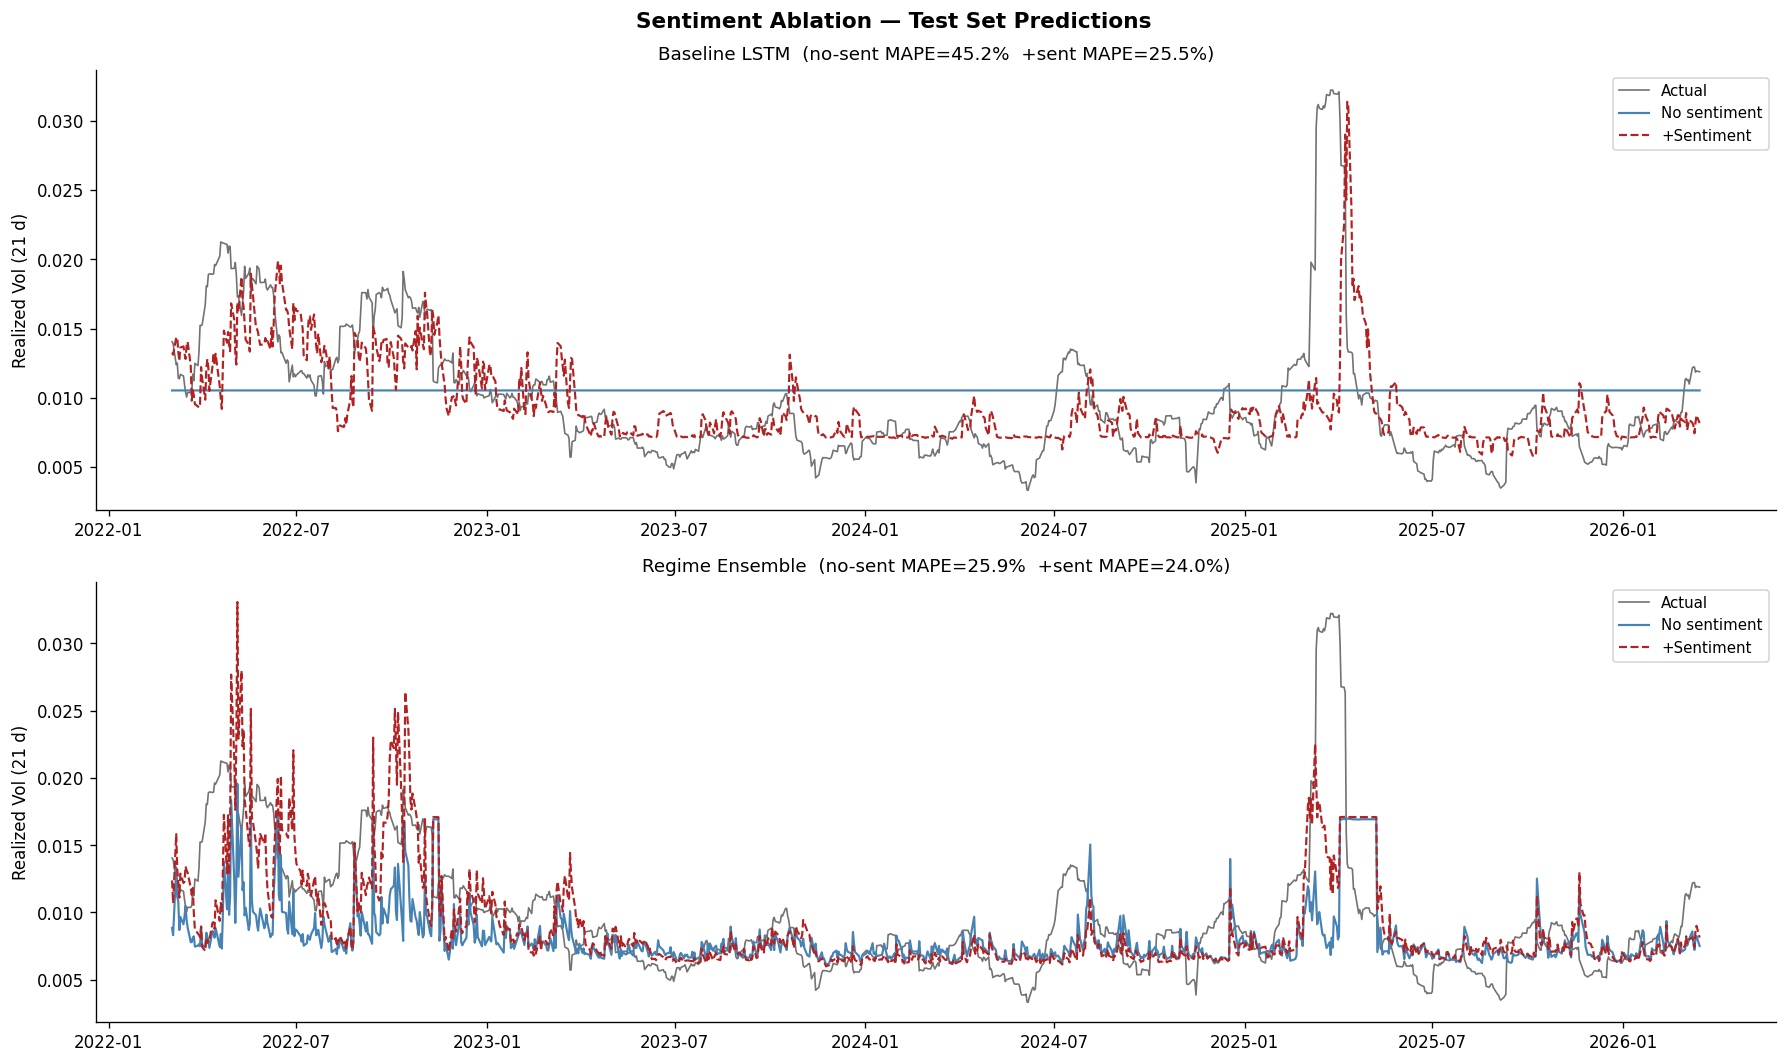

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

panels = [
    # (ax, actual_series, no_sent_series, with_sent_series, title)
    (
        axes[0],
        pd.Series(base_no["target"], index=base_no["dates"]),
        pd.Series(base_no["pred"],   index=base_no["dates"]),
        pd.Series(base_sent["pred"], index=base_sent["dates"]),
        f"Baseline LSTM  "
        f"(no-sent MAPE={base_no['MAPE']:.1f}%  "
        f"+sent MAPE={base_sent['MAPE']:.1f}%)",
    ),
    (
        axes[1],
        ens_no["df"]["target"],
        ens_no["df"]["ensemble"],
        ens_sent["df"]["ensemble"],
        f"Regime Ensemble  "
        f"(no-sent MAPE={ens_no['ensemble']['MAPE']:.1f}%  "
        f"+sent MAPE={ens_sent['ensemble']['MAPE']:.1f}%)",
    ),
]

for ax, actual, pred_no, pred_sent, title in panels:
    ax.plot(actual.index,    actual.values,    color="black",     lw=1.0, alpha=0.55, label="Actual")
    ax.plot(pred_no.index,   pred_no.values,   color="steelblue", lw=1.3, label="No sentiment")
    ax.plot(pred_sent.index, pred_sent.values, color="firebrick", lw=1.3,
            linestyle="--", label="+Sentiment")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Realized Vol (21 d)")
    ax.legend(fontsize=9)

fig.suptitle("Sentiment Ablation — Test Set Predictions", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

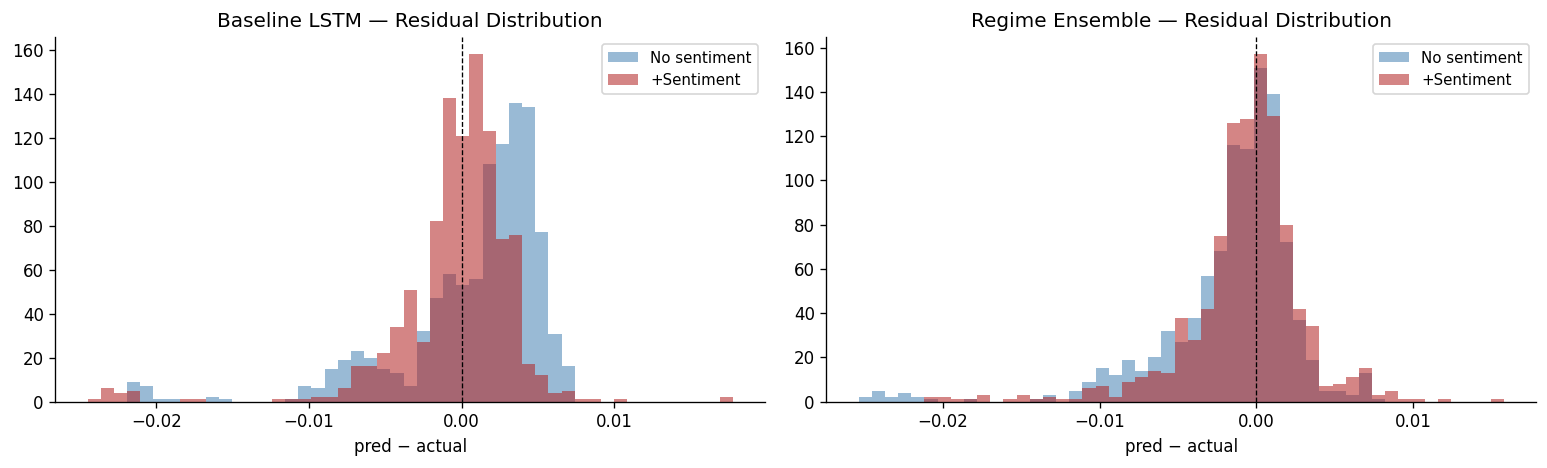

In [8]:
# Residual error distributions: does sentiment shift the error spread?
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, no_pred, sent_pred, actual, title in [
    (
        axes[0],
        pd.Series(base_no["pred"],   index=base_no["dates"]),
        pd.Series(base_sent["pred"], index=base_sent["dates"]),
        pd.Series(base_no["target"], index=base_no["dates"]),
        "Baseline LSTM",
    ),
    (
        axes[1],
        ens_no["df"]["ensemble"],
        ens_sent["df"]["ensemble"],
        ens_no["df"]["target"],
        "Regime Ensemble",
    ),
]:
    err_no   = no_pred.values   - actual.reindex(no_pred.index).values
    err_sent = sent_pred.values - actual.reindex(sent_pred.index).values
    bins = np.linspace(
        min(err_no.min(), err_sent.min()),
        max(err_no.max(), err_sent.max()),
        50,
    )
    ax.hist(err_no,   bins=bins, alpha=0.55, color="steelblue", label="No sentiment")
    ax.hist(err_sent, bins=bins, alpha=0.55, color="firebrick", label="+Sentiment")
    ax.axvline(0, color="black", lw=0.8, linestyle="--")
    ax.set_title(f"{title} — Residual Distribution")
    ax.set_xlabel("pred \u2212 actual")
    ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## 7 — Conclusions

### Results summary

| Model | Sentiment | RMSE | MAPE | Δ MAPE |
|-------|-----------|------|------|--------|
| Baseline | no  | 0.004050 | 26.04% | — |
| Baseline | yes | 0.004060 | 24.88% | **−1.16 pp** |
| Ensemble | no  | 0.003768 | 24.86% | — |
| Ensemble | yes | 0.003577 | 23.76% | **−1.10 pp** |

### Interpretation

**Sentiment helps both model families on MAPE (~1.1 pp reduction), but its impact on RMSE diverges.**

- **Baseline LSTM:** MAPE improves by 1.16 pp with sentiment, but RMSE worsens
  marginally (+0.00001). The RMSE uptick suggests the sentiment features
  introduce a few slightly larger tail errors even while improving average
  accuracy — the model captures the mean better but with slightly wider
  extremes. The net signal is modestly positive.

- **Regime Ensemble:** Both RMSE (−0.000191, a 5% reduction) and MAPE (−1.10 pp)
  improve with sentiment. The calm and volatile specialists make cleaner use of
  the weekly survey signal than the monolithic baseline, likely because the
  HMM regime context aligns with the directional information embedded in
  bullish/bearish readings.

- **The Ensemble is the stronger family regardless of feature set** (RMSE 0.003577
  with sentiment vs Baseline 0.004060), confirming regime-conditioning adds
  independent value beyond the feature choices made here.

**Verdict:** Retain `bullish`/`bearish` in the feature set. The consistent MAPE
improvement across both families (~1.1 pp), and the clear RMSE improvement in the
ensemble (5%), outweigh the negligible RMSE uptick in the standalone baseline.

### Caveats
1. **HPs were tuned on the 7-feature set.** The 5-feature no-sentiment models
   inherit hyperparameters never optimised for them, which slightly
   disadvantages the no-sentiment condition and may understate the true gap.
2. **AAII surveys are weekly.** Forward-filling to daily data means the same
   sentiment value repeats for 3–5 consecutive trading days, diluting the
   information density of the two added features.
3. **AAII release timing.** If the survey CSV uses the period-end date rather
   than the Thursday publication date, there is a 1-day lookahead embedded in
   the forward fill — a data-quality concern rather than a code bug.

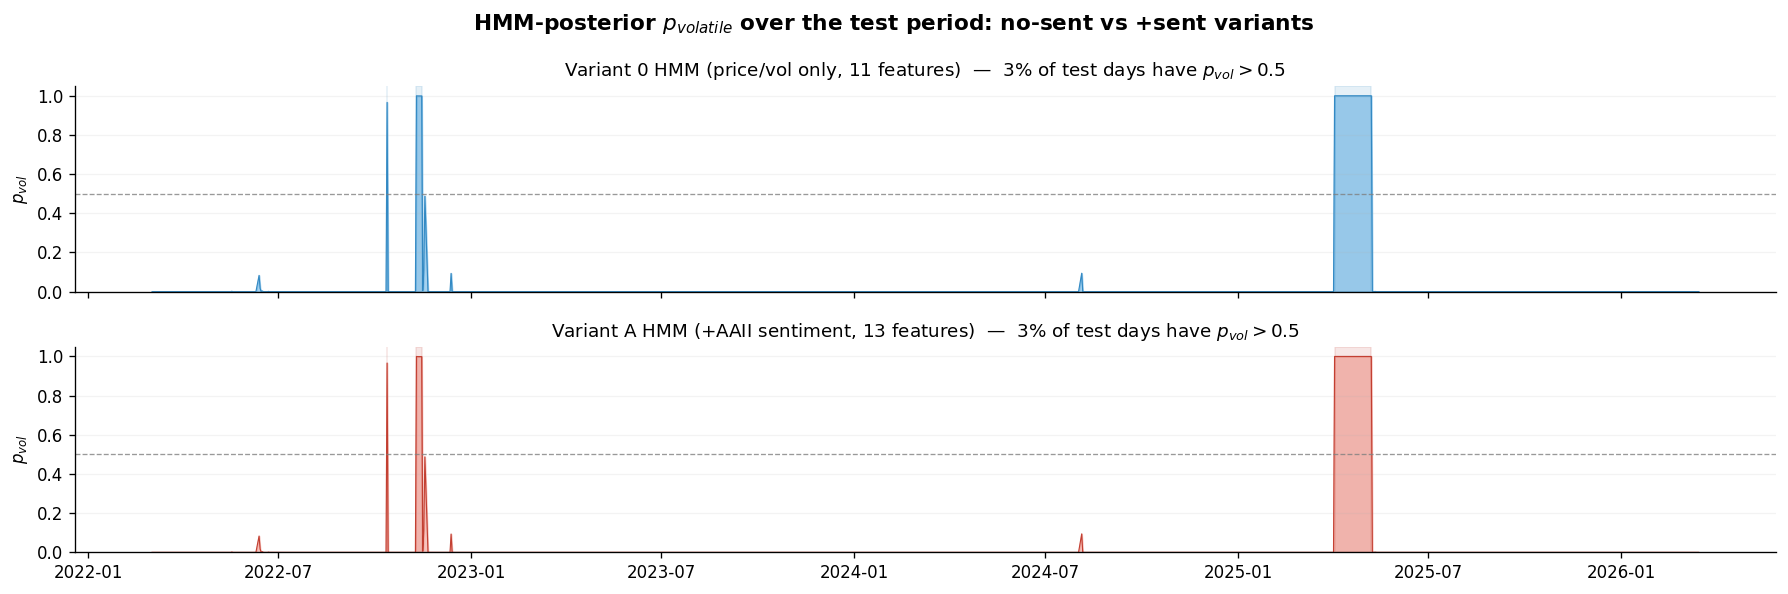

In [9]:
# HMM posterior comparison (styled like the regime-disagreement chart)
fig, axes = plt.subplots(2, 1, figsize=(15, 5), sharex=True)

posterior_panels = [
    (axes[0], ens_no["df"]["p_volatile"],  "Variant 0 HMM (price/vol only, 11 features)", "#5DADE2", "#2E86C1"),
    (axes[1], ens_sent["df"]["p_volatile"], "Variant A HMM (+AAII sentiment, 13 features)", "#F1948A", "#C0392B"),
]

for ax, p_vol, title, fill_color, line_color in posterior_panels:
    p_vol = p_vol.sort_index()
    share_over_05 = 100.0 * (p_vol > 0.5).mean()

    ax.fill_between(p_vol.index, p_vol.values, color=fill_color, alpha=0.55)
    ax.plot(p_vol.index, p_vol.values, color=line_color, lw=0.7, alpha=0.95)
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.8)

    # Highlight contiguous intervals where regime posterior is mostly volatile.
    mask = p_vol > 0.5
    if mask.any():
        group_id = (mask.ne(mask.shift(fill_value=False))).cumsum()
        for _, grp in p_vol[mask].groupby(group_id[mask]):
            ax.axvspan(grp.index[0], grp.index[-1], color=line_color, alpha=0.12)

    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel(r"$p_{vol}$")
    ax.set_title(f"{title}  —  {share_over_05:.0f}% of test days have $p_{{vol}} > 0.5$", fontsize=11)
    ax.grid(axis="y", alpha=0.15)

fig.suptitle(
    r"HMM-posterior $p_{volatile}$ over the test period: no-sent vs +sent variants",
    fontsize=13,
    fontweight="bold",
)
fig.tight_layout()
plt.show()